In [7]:
# import os
# import json
# import glob
# import statistics
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import shapiro, ttest_rel, wilcoxon

# # ========== 可視化の最小設定 ==========
# FONTS = dict(title=14, label=12, legend=10, tick=10)

# def analyze_cv_metrics(
#     base_figures_dir="figures",
#     experience_level=None,
#     image_set=None,
#     specific_image=None,
#     max_length=75,
#     outdir_root=None,          # ← None のとき自動で 'fig/im03/maxlen{max_length}/rat_comparison'
#     min_samples=3,
#     do_plot=True
# ):
#     """
#     指定条件の CV JSON を読み込み、Active vs Passive を統計比較（Shapiro→paired t→Wilcoxon）。
#     発火平均 (FiringRate_*.json) があれば左パネルに併載。右パネルは CV。
#     図は outdir_root/{experience_level}/{image_set}/{specific_image}/ に保存。

#     Returns:
#       {
#         "n": int,
#         "mean_cv_ac": float,
#         "mean_cv_pa": float,
#         "stats": { "shapiro_p":..., "ttest_p":..., "wilcoxon_p":..., "cohens_d_paired":... },
#         "figure_path": "....pdf",
#         "used_cv_files": [ ... ]
#       }
#     """
#     # -------- 入力探索 --------
#     cv_dir = None
#     if experience_level and image_set:
#         cv_dir = os.path.join(base_figures_dir, experience_level, image_set, "CV_metrics")
#         pattern = f"CV_{experience_level}_Set_{image_set}_Image_{specific_image}.json" if specific_image else "*.json"
#         search_pattern = os.path.join(cv_dir, pattern)
#     else:
#         search_pattern = os.path.join(base_figures_dir, "*", "*", "CV_metrics", "*.json")

#     cv_files = sorted(glob.glob(search_pattern))
#     if not cv_files:
#         print("該当するCV指標ファイルが見つかりませんでした。")
#         return {"n": 0, "used_cv_files": [], "figure_path": None}

#     # -------- 読み込み & 集計 --------
#     all_cv_ac, all_cv_pa = [], []
#     file_results = {}
#     for cv_file in cv_files:
#         with open(cv_file, "r") as f:
#             cv_data = json.load(f)
#         file_results[os.path.basename(cv_file)] = cv_data
#         for _, metrics in cv_data.items():
#             all_cv_ac.append(metrics.get("cv_ac"))
#             all_cv_pa.append(metrics.get("cv_pa"))

#     # 欠損/NaN を除去（ペア保持）
#     y_active = np.array(all_cv_ac, dtype=float)
#     y_passive = np.array(all_cv_pa, dtype=float)
#     mask = np.isfinite(y_active) & np.isfinite(y_passive)
#     y_active, y_passive = y_active[mask], y_passive[mask]
#     differences = y_active - y_passive
#     n = differences.size

#     result = {"n": int(n), "used_cv_files": [os.path.basename(p) for p in cv_files]}

#     if n == 0:
#         print("CVデータが見つかりませんでした。")
#         result.update({"figure_path": None})
#         return result

#     mean_cv_ac = float(np.mean(y_active))
#     mean_cv_pa = float(np.mean(y_passive))
#     result.update({"mean_cv_ac": mean_cv_ac, "mean_cv_pa": mean_cv_pa})

#     print("----- 集計結果 -----")
#     print(f"対象ファイル数: {len(cv_files)}")
#     print(f"全体の平均 CV (Active): {mean_cv_ac:.3f}")
#     print(f"全体の平均 CV (Passive): {mean_cv_pa:.3f}")
#     print(f"\n[compare_active_passive] Sample size = {n}")

#     stats = {"shapiro_p": None, "ttest_p": None, "wilcoxon_p": None, "cohens_d_paired": None}

#     if n < min_samples:
#         print(f"  サンプル数が {n} なので、検定をスキップします。")
#         wilcoxon_annotation = None
#     else:
#         # Shapiro（差分の正規性）
#         try:
#             _, p_sw = shapiro(differences)
#         except Exception:
#             p_sw = np.nan
#         stats["shapiro_p"] = float(p_sw)
#         print(f"[Shapiro-Wilk] p = {p_sw:.4g}")

#         # 対応あり t 検定
#         t_stat, p_t = ttest_rel(y_active, y_passive)
#         stats["ttest_p"] = float(p_t)
#         print(f"[Paired t-test] t = {t_stat:.4f}, p = {p_t:.4g}")

#         # Wilcoxon（差が全て0等で例外あり得る）
#         try:
#             w_stat, p_w = wilcoxon(y_active, y_passive)
#             stats["wilcoxon_p"] = float(p_w)
#             wilcoxon_annotation = f"Wilcoxon p = {p_w:.4g}"
#             print(f"[Wilcoxon] W = {w_stat:.4f}, p = {p_w:.4g}")
#         except Exception as e:
#             wilcoxon_annotation = "Wilcoxon: n/a"
#             print(f"[Wilcoxon] skipped: {e}")

#         # 効果量（paired d = mean(diff)/sd(diff)）
#         sd_diff = np.std(differences, ddof=1) if n > 1 else np.nan
#         d_paired = float(np.nan) if (not np.isfinite(sd_diff) or sd_diff == 0) else float(np.mean(differences) / sd_diff)
#         stats["cohens_d_paired"] = d_paired
#         print(f"[Cohen’s d (paired)] d = {d_paired:.4f}")

#     result["stats"] = stats

#     # -------- 可視化 --------
#     figure_path = None
#     if do_plot:
#         # 右図用（CV）：マウス毎のペア線のために dict へ復元
#         combined_cv = {}
#         for file_data in file_results.values():
#             for k, v in file_data.items():
#                 if v.get("cv_ac") is None or v.get("cv_pa") is None: 
#                     continue
#                 combined_cv[k] = {"cv_ac": v["cv_ac"], "cv_pa": v["cv_pa"]}

#         # 左図用（発火平均）
#         combined_firing = {}
#         wilcoxon_annotation_firing = None
#         if cv_dir is not None and specific_image is not None:
#             firing_path = os.path.join(
#                 cv_dir, f"FiringRate_{experience_level}_Set_{image_set}_Image_{specific_image}.json"
#             )
#             if os.path.exists(firing_path):
#                 with open(firing_path, "r") as f:
#                     combined_firing = json.load(f)
#                 # 発火平均の Wilcoxon
#                 fr_a, fr_p = [], []
#                 for _, m in combined_firing.items():
#                     a, p = m.get("mean_rate_ac"), m.get("mean_rate_pa")
#                     if a is not None and p is not None and np.isfinite(a) and np.isfinite(p):
#                         fr_a.append(a); fr_p.append(p)
#                 if len(fr_a) >= min_samples:
#                     try:
#                         _, p_fw = wilcoxon(fr_a, fr_p)
#                         wilcoxon_annotation_firing = f"Wilcoxon p = {p_fw:.4g}"
#                     except Exception as e:
#                         wilcoxon_annotation_firing = "Wilcoxon: n/a"
#                         print(f"[Wilcoxon firing] skipped: {e}")

#         # 図作成
#         fig, axs = plt.subplots(1, 2, figsize=(10, 5))

#         _plot_pairpanel(
#             axs[0], combined_firing, key_a="mean_rate_ac", key_p="mean_rate_pa",
#             title="Mean spikes (all mice)", annotation=wilcoxon_annotation_firing
#         )
#         _plot_pairpanel(
#             axs[1], combined_cv, key_a="cv_ac", key_p="cv_pa",
#             title="CV Values (all mice)", annotation=(wilcoxon_annotation if n >= min_samples else None)
#         )
#         fig.text(0.13, 0.95, "A", fontsize=16, fontweight='bold', ha='center', va='center')
#         fig.text(0.55, 0.95, "B", fontsize=16, fontweight='bold', ha='center', va='center')

#         # 保存先（ご指定どおり）
#         if outdir_root is None:
#             outdir_root = os.path.join('fig', 'im03', f'maxlen{max_length}', 'rat_comparison')
#         save_dir = outdir_root
#         if experience_level: save_dir = os.path.join(save_dir, experience_level)
#         if image_set:        save_dir = os.path.join(save_dir, image_set)
#         if specific_image:   save_dir = os.path.join(save_dir, specific_image)
#         os.makedirs(save_dir, exist_ok=True)

#         figure_filename = (
#             "S3 Fig. Comparison of mean spike rates and coefficient of variation in the active and passive conditions.pdf"
#         )
#         figure_path = os.path.join(save_dir, figure_filename)

#         fig.savefig(figure_path, bbox_inches="tight")
#         plt.show()
#         print(f"Figure saved: {figure_path}")
#     result["figure_path"] = figure_path
#     return result


# def _plot_pairpanel(ax, data_dict, key_a, key_p, title, annotation=None):
#     """Active/Passive のペア線を描く汎用パネル"""
#     x_positions = [0.5, 1.5]
#     ax.set_xticks(x_positions)
#     ax.set_xticklabels(['Active', 'Passive'], fontsize=FONTS["tick"])
#     ax.set_xlim(0, 2)
#     ax.grid(True, alpha=0.3)
#     ax.set_title(title, fontsize=FONTS["title"])

#     # ダミー凡例
#     ax.plot([], [], label='each line = each mouse')

#     # データ描画
#     keys = list(data_dict.keys())
#     if len(keys) == 0:
#         ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
#         return

#     # カラーマップ（マウス数が多くても問題ないように等間隔サンプル）
#     colors = plt.cm.tab10(np.linspace(0, 1, max(2, len(keys))))
#     for i, k in enumerate(keys):
#         m = data_dict[k]
#         a, p = m.get(key_a), m.get(key_p)
#         if a is None or p is None or not (np.isfinite(a) and np.isfinite(p)):
#             continue
#         ax.plot(x_positions, [a, p], marker='o', linestyle='-', color=colors[i % len(colors)], alpha=0.9)

#     ax.legend(loc='best', fontsize=FONTS["legend"])
#     if annotation:
#         ax.text(0.98, 0.10, annotation, transform=ax.transAxes,
#                 fontsize=FONTS["tick"], va='bottom', ha='right',
#                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_rel, wilcoxon

FONTS = dict(title=14, label=12, legend=10, tick=10)

def analyze_cv_metrics(
    base_figures_dir="figures",
    experience_level=None,
    image_set=None,
    specific_image=None,
    max_length=75,
    outdir_root=None,          # ★ これを読み込み側のルートとしても使う
    min_samples=3,
    do_plot=True
):
    """
    CV/FiringRate の参照元:
      outdir_root/{experience_level}/{image_set}/{specific_image}/CV_metrics/*.json
    ※ outdir_root を与えない場合のみ、旧来の figures/.../CV_metrics を参照。
    保存先も outdir_root 側。
    """

    # -------- 参照ルートを決定（優先: outdir_root）--------
    if outdir_root is None:
        # 既定は論文用出力ディレクトリ
        outdir_root = os.path.join('fig', 'im03', f'maxlen{max_length}', 'rat_comparison')
        # 互換確保: 明示的に figures を使いたいケースだけ base_figures_dir を見る
        cv_root = base_figures_dir
    else:
        cv_root = outdir_root  # ★ ここが新

    # -------- CV JSON の探索パターン --------
    if experience_level and image_set:
        if specific_image:
            # 新配置: outdir_root/exp/set/image/CV_metrics/*.json
            cv_dir_new = os.path.join(cv_root, experience_level, image_set, specific_image, "CV_metrics")
            pattern = f"CV_{experience_level}_Set_{image_set}_Image_{specific_image}.json"
            search_patterns = [os.path.join(cv_dir_new, pattern)]
            # 互換: 旧配置 (figures/exp/set/CV_metrics/*.json) もフォールバック
            cv_dir_old = os.path.join(base_figures_dir, experience_level, image_set, "CV_metrics")
            search_patterns.append(os.path.join(cv_dir_old, pattern))
        else:
            # 画像未指定: 新配置は image の階層をワイルドカードで総なめ
            search_patterns = [
                os.path.join(cv_root,        experience_level, image_set, "*", "CV_metrics", "*.json"),
                os.path.join(base_figures_dir, experience_level, image_set,      "CV_metrics", "*.json"),  # 旧配置
            ]
    else:
        # 完全ワイルドカード（新旧どちらも拾う）
        search_patterns = [
            os.path.join(cv_root,         "*", "*", "*", "CV_metrics", "*.json"),  # 新配置
            os.path.join(base_figures_dir,"*", "*",      "CV_metrics", "*.json"),  # 旧配置
        ]

    cv_files = sorted({p for pat in search_patterns for p in glob.glob(pat)})
    if not cv_files:
        print("該当するCV指標ファイルが見つかりませんでした。")
        return {"n": 0, "used_cv_files": [], "figure_path": None}

    # -------- 読み込み & 集計 --------
    all_cv_ac, all_cv_pa = [], []
    file_results = {}
    for cv_file in cv_files:
        with open(cv_file, "r") as f:
            cv_data = json.load(f)
        file_results[os.path.basename(cv_file)] = cv_data
        for _, metrics in cv_data.items():
            all_cv_ac.append(metrics.get("cv_ac"))
            all_cv_pa.append(metrics.get("cv_pa"))

    # 欠損/NaN を除去（ペア保持）
    y_active = np.array(all_cv_ac, dtype=float)
    y_passive = np.array(all_cv_pa, dtype=float)
    mask = np.isfinite(y_active) & np.isfinite(y_passive)
    y_active, y_passive = y_active[mask], y_passive[mask]
    differences = y_active - y_passive
    n = differences.size

    result = {"n": int(n), "used_cv_files": [os.path.basename(p) for p in cv_files]}
    if n == 0:
        print("CVデータが見つかりませんでした。")
        result.update({"figure_path": None})
        return result

    mean_cv_ac = float(np.mean(y_active))
    mean_cv_pa = float(np.mean(y_passive))
    result.update({"mean_cv_ac": mean_cv_ac, "mean_cv_pa": mean_cv_pa})

    print("----- 集計結果 -----")
    print(f"対象ファイル数: {len(cv_files)}")
    print(f"全体の平均 CV (Active): {mean_cv_ac:.3f}")
    print(f"全体の平均 CV (Passive): {mean_cv_pa:.3f}")
    print(f"\n[compare_active_passive] Sample size = {n}")

    stats = {"shapiro_p": None, "ttest_p": None, "wilcoxon_p": None, "cohens_d_paired": None}
    if n < min_samples:
        print(f"  サンプル数が {n} なので、検定をスキップします。")
        wilcoxon_annotation = None
    else:
        try:
            _, p_sw = shapiro(differences)
        except Exception:
            p_sw = np.nan
        stats["shapiro_p"] = float(p_sw)
        print(f"[Shapiro-Wilk] p = {p_sw:.4g}")

        t_stat, p_t = ttest_rel(y_active, y_passive)
        stats["ttest_p"] = float(p_t)
        print(f"[Paired t-test] t = {t_stat:.4f}, p = {p_t:.4g}")

        try:
            w_stat, p_w = wilcoxon(y_active, y_passive)
            stats["wilcoxon_p"] = float(p_w)
            wilcoxon_annotation = f"Wilcoxon p = {p_w:.4g}"
            print(f"[Wilcoxon] W = {w_stat:.4f}, p = {p_w:.4g}")
        except Exception as e:
            wilcoxon_annotation = "Wilcoxon: n/a"
            print(f"[Wilcoxon] skipped: {e}")

        sd_diff = np.std(differences, ddof=1) if n > 1 else np.nan
        d_paired = float(np.nan) if (not np.isfinite(sd_diff) or sd_diff == 0) else float(np.mean(differences) / sd_diff)
        stats["cohens_d_paired"] = d_paired
        print(f"[Cohen’s d (paired)] d = {d_paired:.4f}")

    result["stats"] = stats

    # -------- 可視化 --------
    figure_path = None
    if do_plot:
        # 右図: CV のペア線用 dict
        combined_cv = {}
        for file_data in file_results.values():
            for k, v in file_data.items():
                a, p = v.get("cv_ac"), v.get("cv_pa")
                if a is None or p is None or not (np.isfinite(a) and np.isfinite(p)):
                    continue
                combined_cv[k] = {"cv_ac": a, "cv_pa": p}

        # 左図: 発火平均 (FiringRate_*.json) は new ルートから参照
        combined_firing = {}
        wilcoxon_annotation_firing = None
        if experience_level and image_set and specific_image:
            fr_dir = os.path.join(cv_root, experience_level, image_set, specific_image, "CV_metrics")  # ★ new
            fr_path = os.path.join(fr_dir, f"FiringRate_{experience_level}_Set_{image_set}_Image_{specific_image}.json")
            if os.path.exists(fr_path):
                with open(fr_path, "r") as f:
                    combined_firing = json.load(f)
                fr_a, fr_p = [], []
                for _, m in combined_firing.items():
                    a, p = m.get("mean_rate_ac"), m.get("mean_rate_pa")
                    if a is not None and p is not None and np.isfinite(a) and np.isfinite(p):
                        fr_a.append(a); fr_p.append(p)
                if len(fr_a) >= min_samples:
                    try:
                        _, p_fw = wilcoxon(fr_a, fr_p)
                        wilcoxon_annotation_firing = f"Wilcoxon p = {p_fw:.4g}"
                    except Exception as e:
                        wilcoxon_annotation_firing = "Wilcoxon: n/a"
                        print(f"[Wilcoxon firing] skipped: {e}")

        # 図作成
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        _plot_pairpanel(axs[0], combined_firing, key_a="mean_rate_ac", key_p="mean_rate_pa",
                        title="Mean spikes (all mice)", annotation=wilcoxon_annotation_firing)
        _plot_pairpanel(axs[1], combined_cv, key_a="cv_ac", key_p="cv_pa",
                        title="CV Values (all mice)", annotation=(wilcoxon_annotation if n >= min_samples else None))
        fig.text(0.13, 0.95, "A", fontsize=16, fontweight='bold', ha='center', va='center')
        fig.text(0.55, 0.95, "B", fontsize=16, fontweight='bold', ha='center', va='center')

        # 保存先（outdir_root 側）
        save_dir = os.path.join(outdir_root, *(x for x in [experience_level, image_set, specific_image] if x))
        os.makedirs(save_dir, exist_ok=True)
        figure_filename = ("S3 Fig. Comparison of mean spike rates and coefficient of variation in the active and passive conditions.pdf")
        figure_path = os.path.join(save_dir, figure_filename)
        fig.savefig(figure_path, bbox_inches="tight")
        plt.show()
        print(f"Figure saved: {figure_path}")

    result["figure_path"] = figure_path
    return result


def _plot_pairpanel(ax, data_dict, key_a, key_p, title, annotation=None):
    x_positions = [0.5, 1.5]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Active', 'Passive'], fontsize=FONTS["tick"])
    ax.set_xlim(0, 2)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=FONTS["title"])
    ax.plot([], [], label='each line = each mouse')

    keys = list(data_dict.keys())
    if len(keys) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return

    colors = plt.cm.tab10(np.linspace(0, 1, max(2, len(keys))))
    for i, k in enumerate(keys):
        m = data_dict[k]
        a, p = m.get(key_a), m.get(key_p)
        if a is None or p is None or not (np.isfinite(a) and np.isfinite(p)):
            continue
        ax.plot(x_positions, [a, p], marker='o', linestyle='-', color=colors[i % len(colors)], alpha=0.9)

    ax.legend(loc='best', fontsize=FONTS["legend"])
    if annotation:
        ax.text(0.98, 0.10, annotation, transform=ax.transAxes,
                fontsize=FONTS["tick"], va='bottom', ha='right',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


----- 集計結果 -----
対象ファイル数: 2
全体の平均 CV (Active): 1.554
全体の平均 CV (Passive): 1.297

[compare_active_passive] Sample size = 74
[Shapiro-Wilk] p = 0.0008604
[Paired t-test] t = 11.0188, p = 3.47e-17
[Wilcoxon] W = 145.0000, p = 2.17e-11
[Cohen’s d (paired)] d = 1.2809


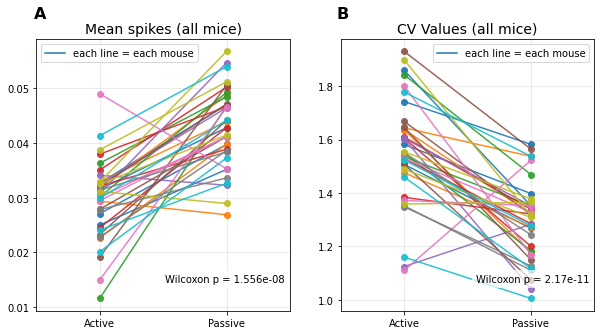

Figure saved: fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r/S3 Fig. Comparison of mean spike rates and coefficient of variation in the active and passive conditions.pdf
{'n': 74, 'used_cv_files': ['CV_Familiar_Set_G_Image_im036_r.json', 'CV_Familiar_Set_G_Image_im036_r.json'], 'mean_cv_ac': 1.554424334860459, 'mean_cv_pa': 1.2971682045203905, 'stats': {'shapiro_p': 0.0008603578899055719, 'ttest_p': 3.469709667041533e-17, 'wilcoxon_p': 2.170179507956648e-11, 'cohens_d_paired': 1.2809123314982844}, 'figure_path': 'fig/im03/maxlen75/rat_comparison/Familiar/G/im036_r/S3 Fig. Comparison of mean spike rates and coefficient of variation in the active and passive conditions.pdf'}


In [8]:
# # 例: Familiar / G / im036_r、max_length=75
# res = analyze_cv_metrics(
#     base_figures_dir="figures",
#     experience_level="Familiar",
#     image_set="G",
#     specific_image="im036_r",
#     max_length=75,
#     outdir_root=os.path.join('fig', 'im03', f'maxlen{75}', 'rat_comparison'),
#     do_plot=True
# )
# print(res)


res = analyze_cv_metrics(
    experience_level="Familiar",
    image_set="G",
    specific_image="im036_r",
    max_length=75,
    outdir_root=os.path.join('fig', 'im03', 'maxlen75', 'rat_comparison'),  # ★ 参照＆保存の両方に使用
    do_plot=True
)
print(res)
